In [241]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [242]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [243]:
ticker = 'AAPL'
df = yf.download(ticker, '2020-01-01')


[*********************100%***********************]  1 of 1 completed


In [244]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267914,72.306483,70.568488,70.819186,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200
...,...,...,...,...,...
2026-03-27,248.800003,255.490005,248.070007,253.899994,47900000
2026-03-30,246.630005,250.869995,245.509995,250.070007,39446200


<Axes: xlabel='Date'>

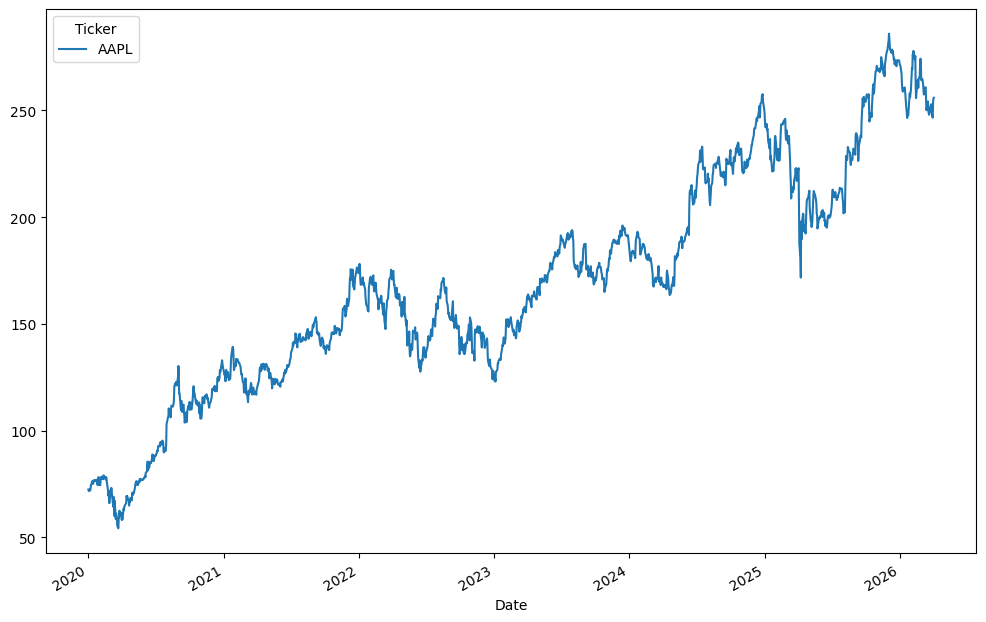

In [245]:
df.Close.plot(figsize=(12, 8))

In [246]:
scaler = StandardScaler()

df['Close'] = scaler.fit_transform(df['Close'])

In [247]:
df.Close

Ticker,AAPL
Date,
2020-01-02,-1.845108
2020-01-03,-1.858608
2020-01-06,-1.847651
2020-01-07,-1.854169
2020-01-08,-1.831978
...,...
2026-03-27,1.538022
2026-03-30,1.496404
2026-03-31,1.633724


In [248]:
seq_length = 30
data = []

for i in range(len(df) - seq_length):
    data.append(df.Close[i:i+seq_length])

data = np.array(data)

In [249]:
data

array([[[-1.84510797],
        [-1.8586077 ],
        [-1.84765135],
        ...,
        [-1.75255994],
        [-1.71738705],
        [-1.72818478]],

       [[-1.8586077 ],
        [-1.84765135],
        [-1.85416944],
        ...,
        [-1.71738705],
        [-1.72818478],
        [-1.72781356]],

       [[-1.84765135],
        [-1.85416944],
        [-1.83197829],
        ...,
        [-1.72818478],
        [-1.72781356],
        [-1.75538689]],

       ...,

       [[ 1.82723839],
        [ 1.83625245],
        [ 1.763948  ],
        ...,
        [ 1.61646328],
        [ 1.53802207],
        [ 1.49640411]],

       [[ 1.83625245],
        [ 1.763948  ],
        [ 1.8406632 ],
        ...,
        [ 1.53802207],
        [ 1.49640411],
        [ 1.63372409]],

       [[ 1.763948  ],
        [ 1.8406632 ],
        [ 1.87134939],
        ...,
        [ 1.49640411],
        [ 1.63372409],
        [ 1.6690133 ]]], shape=(1541, 30, 1))

In [250]:
train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [251]:
X_train

tensor([[[-1.8451],
         [-1.8586],
         [-1.8477],
         ...,
         [-1.7436],
         [-1.7526],
         [-1.7174]],

        [[-1.8586],
         [-1.8477],
         [-1.8542],
         ...,
         [-1.7526],
         [-1.7174],
         [-1.7282]],

        [[-1.8477],
         [-1.8542],
         [-1.8320],
         ...,
         [-1.7174],
         [-1.7282],
         [-1.7278]],

        ...,

        [[ 1.1207],
         [ 1.1344],
         [ 1.1253],
         ...,
         [ 1.6416],
         [ 1.5770],
         [ 1.5430]],

        [[ 1.1344],
         [ 1.1253],
         [ 1.1510],
         ...,
         [ 1.5770],
         [ 1.5430],
         [ 1.4177]],

        [[ 1.1253],
         [ 1.1510],
         [ 1.2082],
         ...,
         [ 1.5430],
         [ 1.4177],
         [ 1.4083]]])

In [252]:
y_train

tensor([[-1.7282],
        [-1.7278],
        [-1.7554],
        ...,
        [ 1.4177],
        [ 1.4083],
        [ 1.4396]])

In [253]:
class PredictionModel(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out

In [254]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

In [255]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [256]:
num_epochs = 200

for i in range(num_epochs):
    y_train_pred = model(X_train)

    loss = criterion(y_train_pred, y_train)

    if i % 25 == 0:
        print(i, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

0 0.8220113515853882
25 0.012818818911910057
50 0.005159797612577677
75 0.004566999152302742
100 0.004158452153205872
125 0.003924330230802298
150 0.003727551316842437
175 0.0035472805611789227


In [257]:
model.eval()

y_test_pred = model(X_test)

y_train_pred = scaler.inverse_transform(y_train_pred.detach().cpu().numpy())
y_train = scaler.inverse_transform(y_train.detach().cpu().numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
y_test = scaler.inverse_transform(y_test.detach().cpu().numpy())

In [258]:
train_rmse = root_mean_squared_error(y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(y_test[:, 0], y_test_pred[:, 0])

In [259]:
train_rmse

3.0341615676879883

In [260]:
test_rmse

5.903679370880127

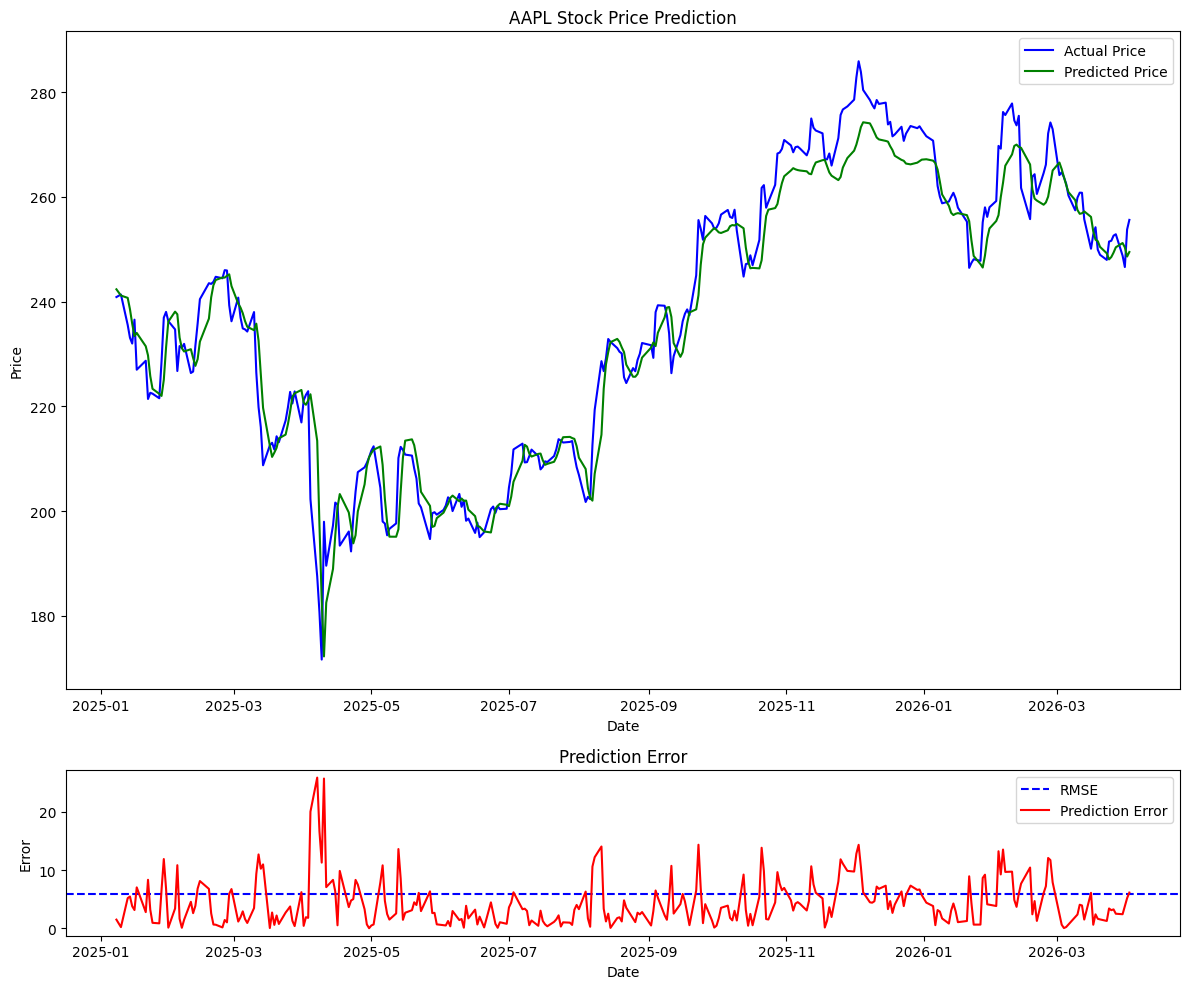

In [263]:
fig = plt.figure(figsize = (12,10))

gs = fig.add_gridspec(4,1)

ax1 = fig.add_subplot(gs[:3,0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color = 'blue', label = 'Actual Price')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color = 'green', label = 'Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel('Date')
plt.ylabel('Price')

ax2 = fig.add_subplot(gs[3,0])
ax2.axhline(test_rmse, color = 'blue', linestyle='--', label='RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label = 'Prediction Error')
ax2.legend()
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')

plt.tight_layout()
plt.show()
